In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from urllib.request import urlretrieve

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1.0 - a)

def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)
    Z3 = np.dot(A2, W3) + b3
    A3 = sigmoid(Z3)
    return Z1, A1, Z2, A2, Z3, A3

def mse_loss(Y_true, Y_pred):
    m = Y_true.shape[0]
    return np.sum((Y_true - Y_pred) ** 2) / m

def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]
    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = np.dot(A2.T, delta3) / m
    db3 = np.sum(delta3, axis=0) / m
    delta2 = np.dot(delta3, W3.T) * sigmoid_derivative(A2)
    dW2 = np.dot(A1.T, delta2) / m
    db2 = np.sum(delta2, axis=0) / m
    delta1 = np.dot(delta2, W2.T) * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, delta1) / m
    db1 = np.sum(delta1, axis=0) / m
    return dW1, db1, dW2, db2, dW3, db3

def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, lr=0.1):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    W3 -= lr * dW3
    b3 -= lr * db3
    return W1, b1, W2, b2, W3, b3

def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

def get_accuracy(Y_true, Y_pred):
    pred = np.argmax(Y_pred, axis=1)
    true = np.argmax(Y_true, axis=1) if Y_true.ndim > 1 else Y_true
    return np.mean(pred == true) * 100.0

In [7]:
def load_mnist():
    print("Loading MNIST dataset...")
    if not os.path.exists('data'):
        os.makedirs('data')
    if not os.path.exists('data/mnist.npz'):
        url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
        urlretrieve(url, 'data/mnist.npz')
        print("Downloaded mnist.npz")
    data = np.load('data/mnist.npz')
    X_train = data['x_train'].reshape(-1, 784) / 255.0
    y_train = data['y_train']
    X_test  = data['x_test'].reshape(-1, 784) / 255.0
    y_test  = data['y_test']
    print(f"Loaded: {X_train.shape[0]} train, {X_test.shape[0]} test samples")
    return X_train, y_train, X_test, y_test

In [8]:
def train():
    X_train, y_train, X_test, y_test = load_mnist()
    Y_train_oh = one_hot(y_train)
    Y_test_oh  = one_hot(y_test)

    np.random.seed(42)
    W1 = np.random.uniform(-0.5, 0.5, (784, 128))
    b1 = np.zeros(128)
    W2 = np.random.uniform(-0.5, 0.5, (128, 64))
    b2 = np.zeros(64)
    W3 = np.random.uniform(-0.5, 0.5, (64, 10))
    b3 = np.zeros(10)

    epochs = 20
    batch_size = 32
    lr = 0.1
    train_loss_history = []
    test_loss_history = []

    print("\nStarting training...\n")
    for epoch in range(epochs):
        idx = np.random.permutation(X_train.shape[0])
        X_shuf = X_train[idx]
        Y_shuf = Y_train_oh[idx]

        for start in range(0, X_train.shape[0], batch_size):
            end = start + batch_size
            Xb = X_shuf[start:end]
            Yb = Y_shuf[start:end]

            Z1, A1, Z2, A2, Z3, A3 = forward_pass(Xb, W1, b1, W2, b2, W3, b3)
            dW1, db1, dW2, db2, dW3, db3 = backpropagation(Xb, Yb, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3)
            W1, b1, W2, b2, W3, b3 = update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, lr)

        # Epoch metrics - both train and test
        _,_,_,_,_,A3_train = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
        train_loss = mse_loss(Y_train_oh, A3_train)
        _,_,_,_,_,A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
        test_loss = mse_loss(Y_test_oh, A3_test)

        train_loss_history.append(train_loss)
        test_loss_history.append(test_loss)

        print(f"Epoch {epoch+1:2d}/{epochs}   Train Loss: {train_loss:.4f}   Test Loss: {test_loss:.4f}")

    _,_,_,_,_,A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
    acc = get_accuracy(Y_test_oh, A3_test)
    print(f"\nTraining finished. Final Test Accuracy: {acc:.2f}%")

    return W1, b1, W2, b2, W3, b3, train_loss_history, test_loss_history, X_test, y_test, Y_test_oh

In [9]:
def plot_loss(train_loss, test_loss):
    plt.figure(figsize=(9,5))
    plt.plot(train_loss, 'b-o', markersize=4, label='Train Loss')
    plt.plot(test_loss,  'r-s', markersize=4, label='Test Loss')
    plt.title('Train vs Test MSE Loss – MNIST')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig('loss_curve.png', dpi=150)
    plt.show()
    print("Loss curve saved as loss_curve.png")

Loading MNIST dataset...
Loaded: 60000 train, 10000 test samples

Starting training...

Epoch  1/20   Train Loss: 0.2957   Test Loss: 0.2900
Epoch  2/20   Train Loss: 0.2078   Test Loss: 0.2026
Epoch  3/20   Train Loss: 0.1723   Test Loss: 0.1666
Epoch  4/20   Train Loss: 0.1530   Test Loss: 0.1485
Epoch  5/20   Train Loss: 0.1381   Test Loss: 0.1343
Epoch  6/20   Train Loss: 0.1271   Test Loss: 0.1247
Epoch  7/20   Train Loss: 0.1188   Test Loss: 0.1168
Epoch  8/20   Train Loss: 0.1114   Test Loss: 0.1111
Epoch  9/20   Train Loss: 0.1054   Test Loss: 0.1057
Epoch 10/20   Train Loss: 0.1001   Test Loss: 0.1011
Epoch 11/20   Train Loss: 0.0954   Test Loss: 0.0974
Epoch 12/20   Train Loss: 0.0912   Test Loss: 0.0940
Epoch 13/20   Train Loss: 0.0879   Test Loss: 0.0915
Epoch 14/20   Train Loss: 0.0841   Test Loss: 0.0879
Epoch 15/20   Train Loss: 0.0811   Test Loss: 0.0858
Epoch 16/20   Train Loss: 0.0783   Test Loss: 0.0835
Epoch 17/20   Train Loss: 0.0764   Test Loss: 0.0821
Epoch 18/20

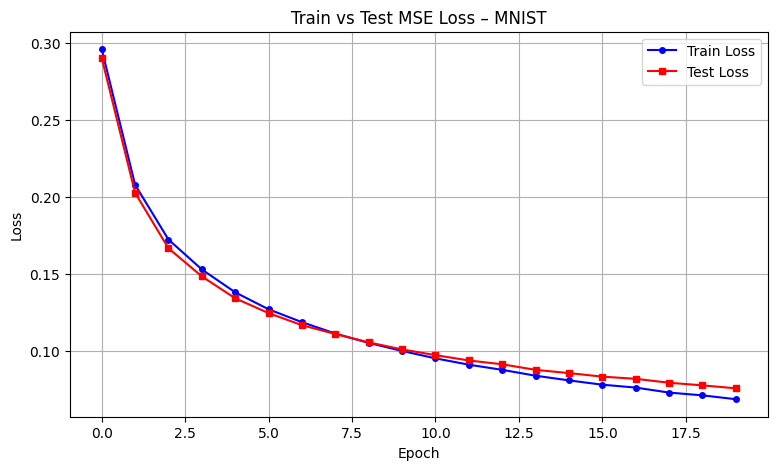

Loss curve saved as loss_curve.png


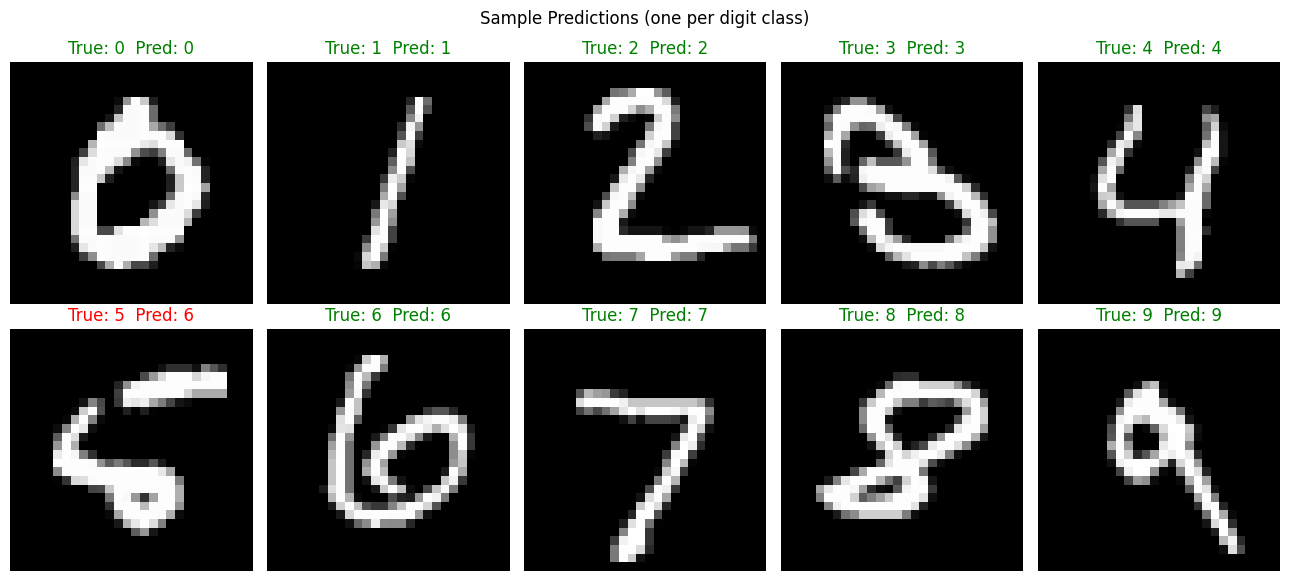

Sample predictions saved as sample_predictions.png


In [10]:
# ====================== RUN ======================
W1, b1, W2, b2, W3, b3, train_loss, test_loss, X_test, y_test, Y_test_oh = train()
plot_loss(train_loss, test_loss)
show_predictions(X_test, y_test, W1, b1, W2, b2, W3, b3, Y_test_oh)